# Logistic Regression
### Predicting whether a student will Pass or Fail based on Hours Studied



## Step 1 — Import Libraries

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score, precision_recall_curve

## Step 2 — Dataset

| Student | Hours Studied | Pass/Fail |
|---------|---------------|-----------|
| A       | 1.0 hour      | 0 (Fail)  |
| B       | 1.5 hours     | 0 (Fail)  |
| C       | 2.0 hours     | 0 (Fail)  |
| D       | 2.5 hours     | 0 (Fail)  |
| E       | 3.0 hours     | 1 (Pass)  |
| F       | 3.5 hours     | 0 (Fail)  |
| G       | 4.0 hours     | 1 (Pass)  |
| H       | 4.5 hours     | 1 (Pass)  |
| I       | 5.0 hours     | 1 (Pass)  |
| J       | 6.0 hours     | 1 (Pass)  |

In [2]:
# Input: hours studied
x = [1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 6]

# Output: 0 = Fail, 1 = Pass
y = [0, 0, 0, 0, 1, 0, 1, 1, 1, 1]

print('Hours studied:', x)
print('Pass or Fail: ', y)
print('Total students:', len(x))

Hours studied: [1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 6]
Pass or Fail:  [0, 0, 0, 0, 1, 0, 1, 1, 1, 1]
Total students: 10


## Step 3 — Sigmoid Function

Sigmoid takes any number and converts it to a probability between 0 and 1.

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- z very negative → output close to 0 (Fail)
- z = 0 → output = 0.5 (unsure)
- z very positive → output close to 1 (Pass)

In [3]:
def sigmoid(z):
    return 1 / (1 + math.exp(-z))

print('sigmoid(-5) =', round(sigmoid(-5), 4), '← close to 0, almost certainly Fail')
print('sigmoid( 0) =', round(sigmoid( 0), 4), '← 0.5, model is unsure')
print('sigmoid( 5) =', round(sigmoid( 5), 4), '← close to 1, almost certainly Pass')

sigmoid(-5) = 0.0067 ← close to 0, almost certainly Fail
sigmoid( 0) = 0.5 ← 0.5, model is unsure
sigmoid( 5) = 0.9933 ← close to 1, almost certainly Pass


## Step 4 — Cross Entropy Loss

Measures how wrong the model is.
- High loss = very wrong
- Low loss = nearly right

$$L = -[y \log(\hat{y}) + (1-y) \log(1-\hat{y})]$$

In [4]:
def cross_entropy_loss(y_true, y_pred):
    # Clip to avoid log(0) which is undefined
    y_pred = max(1e-15, min(1 - 1e-15, y_pred))
    return -(y_true * math.log(y_pred) + (1 - y_true) * math.log(1 - y_pred))

print('Real=1 (Pass), Predicted=0.90 → Loss:', round(cross_entropy_loss(1, 0.90), 4), '(low = good)')
print('Real=1 (Pass), Predicted=0.10 → Loss:', round(cross_entropy_loss(1, 0.10), 4), '(high = bad)')
print('Real=0 (Fail), Predicted=0.10 → Loss:', round(cross_entropy_loss(0, 0.10), 4), '(low = good)')
print('Real=0 (Fail), Predicted=0.90 → Loss:', round(cross_entropy_loss(0, 0.90), 4), '(high = bad)')

Real=1 (Pass), Predicted=0.90 → Loss: 0.1054 (low = good)
Real=1 (Pass), Predicted=0.10 → Loss: 2.3026 (high = bad)
Real=0 (Fail), Predicted=0.10 → Loss: 0.1054 (low = good)
Real=0 (Fail), Predicted=0.90 → Loss: 2.3026 (high = bad)


## Step 5 — Numerical Stability

When z is very large or very small, `math.exp()` can overflow and crash.
We fix this by handling positive and negative z separately.

Testing with z = -500:
Unstable sigmoid: 7.124576406741285e-218
Stable sigmoid:   0.0 ← works fine!


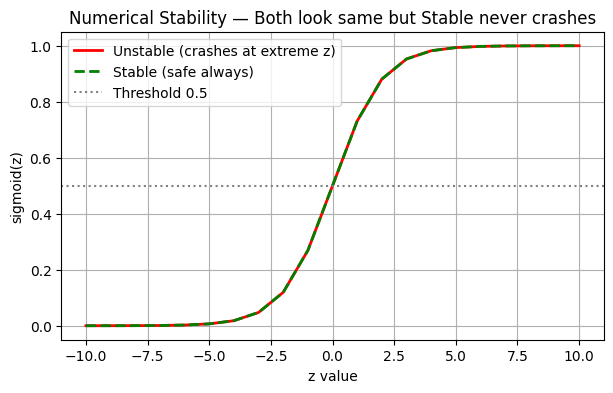

Both curves look the same for normal values
But stable sigmoid never crashes for extreme values like -500 or 1000


In [5]:
# Regular sigmoid — crashes with extreme values
def sigmoid_unstable(z):
    return 1 / (1 + math.exp(-z))

# Stable sigmoid — safe for all values
def sigmoid_stable(z):
    if z >= 0:
        return 1 / (1 + math.exp(-z))
    else:
        return math.exp(z) / (1 + math.exp(z))

# Show the crash
print('Testing with z = -500:')
try:
    print('Unstable sigmoid:', sigmoid_unstable(-500))
except OverflowError:
    print('Unstable sigmoid: CRASHED! OverflowError')
print('Stable sigmoid:  ', round(sigmoid_stable(-500), 6), '← works fine!')

# Graph: compare both
z_values        = list(range(-10, 11))
stable_values   = [sigmoid_stable(z)   for z in z_values]
unstable_values = [sigmoid_unstable(z) for z in z_values]

plt.figure(figsize=(7, 4))
plt.plot(z_values, unstable_values, color='red',   linewidth=2, label='Unstable (crashes at extreme z)')
plt.plot(z_values, stable_values,   color='green', linewidth=2, linestyle='--', label='Stable (safe always)')
plt.axhline(y=0.5, color='gray', linestyle=':', label='Threshold 0.5')
plt.title('Numerical Stability — Both look same but Stable never crashes')
plt.xlabel('z value')
plt.ylabel('sigmoid(z)')
plt.legend()
plt.grid(True)
plt.show()

print('Both curves look the same for normal values')
print('But stable sigmoid never crashes for extreme values like -500 or 1000')

## Step 6 — Gradient Descent Training Loop



In [6]:
# Starting values
w = 0.5
b = 0.0
learning_rate = 0.1
epochs = 1000
loss_history = []

for epoch in range(epochs):

    predictions = []
    total_loss  = 0

    # Step 1 and 2: Calculate z and apply sigmoid for each student
    for xi in x:
        z      = w * xi + b
        y_pred = sigmoid_stable(z)
        predictions.append(y_pred)

    # Step 3: Calculate average loss
    for yi, y_pred in zip(y, predictions):
        total_loss += cross_entropy_loss(yi, y_pred)
    avg_loss = total_loss / len(y)
    loss_history.append(avg_loss)

    # Step 4: Calculate gradients
    grad_w = 0
    grad_b = 0
    for xi, yi, y_pred in zip(x, y, predictions):
        grad_w += xi * (y_pred - yi)
        grad_b += (y_pred - yi)
    grad_w = grad_w / len(y)
    grad_b = grad_b / len(y)

    # Step 5: Update w and b
    w = w - learning_rate * grad_w
    b = b - learning_rate * grad_b

    if epoch % 200 == 0:
        print(f'Epoch {epoch:4d} | Loss: {avg_loss:.4f} | w: {w:.4f} | b: {b:.4f}')

print()
print('Training complete!')
print(f'Final w = {w:.4f}')
print(f'Final b = {b:.4f}')

Epoch    0 | Loss: 0.7392 | w: 0.4409 | b: -0.0314
Epoch  200 | Loss: 0.4064 | w: 0.7414 | b: -2.0688
Epoch  400 | Loss: 0.3386 | w: 1.0557 | b: -3.1778
Epoch  600 | Loss: 0.3080 | w: 1.2705 | b: -3.9247
Epoch  800 | Loss: 0.2912 | w: 1.4316 | b: -4.4805

Training complete!
Final w = 1.5587
Final b = -4.9169


## Step 7 — Plot Loss Curve

Loss should go DOWN over epochs — this proves the model is learning

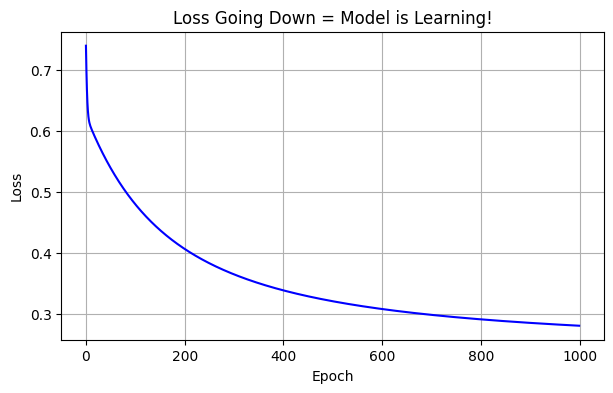

Starting loss: 0.7392
Final loss:    0.2807


In [7]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history, color='blue')
plt.title('Loss Going Down = Model is Learning!')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

print(f'Starting loss: {loss_history[0]:.4f}')
print(f'Final loss:    {loss_history[-1]:.4f}')

## Step 8 — Visualization of Decision Boundary

Decision boundary = the point where model switches from Fail to Pass.
This happens when wx + b = 0, so x = -b/w

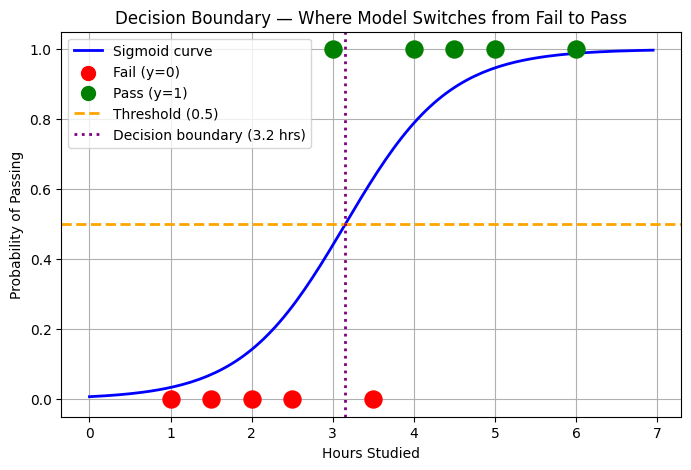

Decision boundary at 3.15 hours
Study MORE than 3.15 hours → PASS
Study LESS than 3.15 hours → FAIL


In [8]:
# Generate smooth curve
x_line    = [i * 0.05 for i in range(0, 140)]
y_line    = [sigmoid_stable(w * xi + b) for xi in x_line]
boundary  = -b / w

plt.figure(figsize=(8, 5))
plt.plot(x_line, y_line, color='blue', linewidth=2, label='Sigmoid curve')

# Plot Fail points in red, Pass points in green
for xi, yi in zip(x, y):
    color = 'red' if yi == 0 else 'green'
    plt.scatter(xi, yi, color=color, s=150, zorder=5)

plt.scatter([], [], color='red',   s=100, label='Fail (y=0)')
plt.scatter([], [], color='green', s=100, label='Pass (y=1)')
plt.axhline(y=0.5, color='orange', linestyle='--', linewidth=2, label='Threshold (0.5)')
plt.axvline(x=boundary, color='purple', linestyle=':', linewidth=2, label=f'Decision boundary ({boundary:.1f} hrs)')

plt.title('Decision Boundary — Where Model Switches from Fail to Pass')
plt.xlabel('Hours Studied')
plt.ylabel('Probability of Passing')
plt.legend()
plt.grid(True)
plt.show()

print(f'Decision boundary at {boundary:.2f} hours')
print(f'Study MORE than {boundary:.2f} hours → PASS')
print(f'Study LESS than {boundary:.2f} hours → FAIL')

## Step 9 — Make Predictions

In [9]:
def predict(hours):
    z           = w * hours + b
    probability = sigmoid_stable(z)
    result      = 'PASS' if probability >= 0.5 else 'FAIL'
    print(f'Hours: {hours} | Probability: {probability:.2f} | Prediction: {result}')
    return 1 if probability >= 0.5 else 0

print('--- Original students ---')
predict(1)
predict(2)
predict(3)
predict(5)
print()
print('--- New students ---')
predict(4)
predict(6)
predict(0.5)

--- Original students ---
Hours: 1 | Probability: 0.03 | Prediction: FAIL
Hours: 2 | Probability: 0.14 | Prediction: FAIL
Hours: 3 | Probability: 0.44 | Prediction: FAIL
Hours: 5 | Probability: 0.95 | Prediction: PASS

--- New students ---
Hours: 4 | Probability: 0.79 | Prediction: PASS
Hours: 6 | Probability: 0.99 | Prediction: PASS
Hours: 0.5 | Probability: 0.02 | Prediction: FAIL


0

## Step 10 — Evaluation Metrics
### Confusion Matrix, ROC Curve, AUC, Precision and Recall

In [10]:
# Get all predictions and probabilities
y_pred_labels = [predict(xi) for xi in x]
y_prob        = [sigmoid_stable(w * xi + b) for xi in x]

correct = sum(1 for pred, real in zip(y_pred_labels, y) if pred == real)
print(f'Accuracy: {correct}/{len(y)} = {correct/len(y)*100:.1f}%')

Hours: 1 | Probability: 0.03 | Prediction: FAIL
Hours: 1.5 | Probability: 0.07 | Prediction: FAIL
Hours: 2 | Probability: 0.14 | Prediction: FAIL
Hours: 2.5 | Probability: 0.27 | Prediction: FAIL
Hours: 3 | Probability: 0.44 | Prediction: FAIL
Hours: 3.5 | Probability: 0.63 | Prediction: PASS
Hours: 4 | Probability: 0.79 | Prediction: PASS
Hours: 4.5 | Probability: 0.89 | Prediction: PASS
Hours: 5 | Probability: 0.95 | Prediction: PASS
Hours: 6 | Probability: 0.99 | Prediction: PASS
Accuracy: 8/10 = 80.0%


<Figure size 500x400 with 0 Axes>

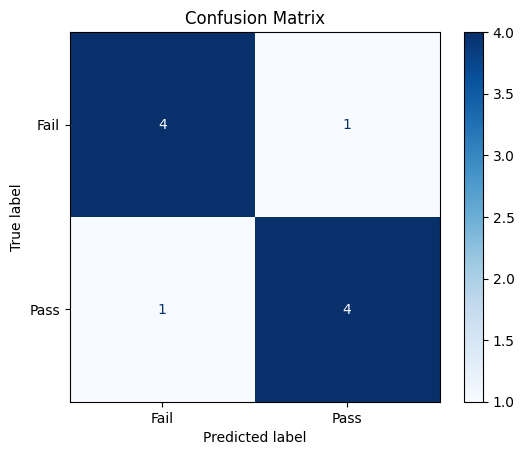

True Negatives  (correctly said Fail): 4
False Positives (wrongly said Pass):   1
False Negatives (wrongly said Fail):   1
True Positives  (correctly said Pass): 4


In [11]:
# --- Confusion Matrix ---
cm = confusion_matrix(y, y_pred_labels)

plt.figure(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

print(f'True Negatives  (correctly said Fail): {cm[0][0]}')
print(f'False Positives (wrongly said Pass):   {cm[0][1]}')
print(f'False Negatives (wrongly said Fail):   {cm[1][0]}')
print(f'True Positives  (correctly said Pass): {cm[1][1]}')

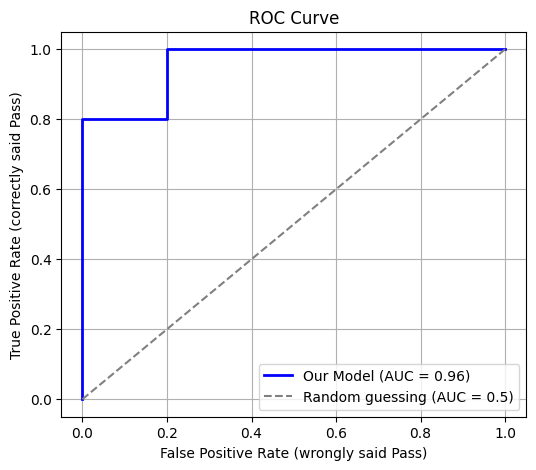

AUC Score: 0.96
AUC = 1.0 → perfect model
AUC = 0.5 → random guessing



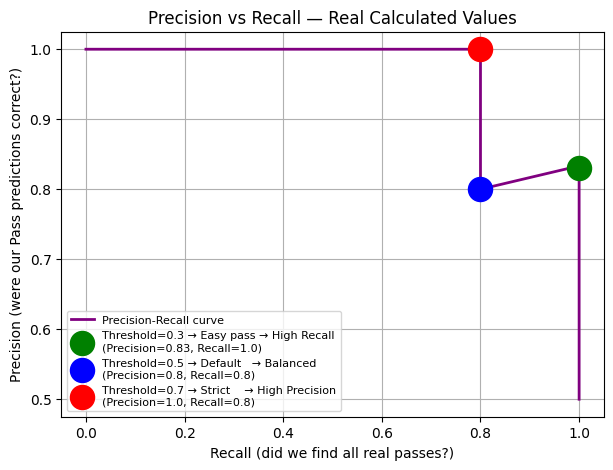

REAL CALCULATED VALUES:
Threshold=0.3 → Precision=0.83, Recall=1.0 → Easy pass → High Recall
Threshold=0.5 → Precision=0.8, Recall=0.8 → Default   → Balanced
Threshold=0.7 → Precision=1.0, Recall=0.8 → Strict    → High Precision

WHICH DO WE PREFER?
Cancer detection → missing real cancer is dangerous → prefer HIGH RECALL → lower threshold
Spam filter      → blocking real emails is bad      → prefer HIGH PRECISION → higher threshold


In [12]:
# Get probabilities
y_prob = [sigmoid_stable(w * xi + b) for xi in x]

# --- Graph 1: ROC Curve ---
fpr, tpr, _ = roc_curve(y, y_prob)
auc_score   = roc_auc_score(y, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'Our Model (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guessing (AUC = 0.5)')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate (wrongly said Pass)')
plt.ylabel('True Positive Rate (correctly said Pass)')
plt.legend()
plt.grid(True)
plt.show()

print(f'AUC Score: {auc_score:.2f}')
print('AUC = 1.0 → perfect model')
print('AUC = 0.5 → random guessing')
print()

# --- Graph 2: Real Precision Recall Curve ---
# Using real calculated values from our data
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y, y_prob)

# Calculate precision and recall at 3 specific thresholds
test_thresholds = [0.3, 0.5, 0.7]
colors = ['green', 'blue', 'red']
labels = [
    'Threshold=0.3 → Easy pass → High Recall',
    'Threshold=0.5 → Default   → Balanced',
    'Threshold=0.7 → Strict    → High Precision'
]

thresh_precision = []
thresh_recall    = []

for thresh in test_thresholds:
    preds = [1 if p >= thresh else 0 for p in y_prob]
    tp = sum(1 for p, r in zip(preds, y) if p == 1 and r == 1)
    fp = sum(1 for p, r in zip(preds, y) if p == 1 and r == 0)
    fn = sum(1 for p, r in zip(preds, y) if p == 0 and r == 1)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    thresh_precision.append(round(prec, 2))
    thresh_recall.append(round(rec, 2))

# Plot precision recall curve
plt.figure(figsize=(7, 5))
plt.plot(recall_vals, precision_vals, color='purple', linewidth=2, label='Precision-Recall curve')

# Plot 3 threshold dots on the curve
for prec, rec, color, label in zip(thresh_precision, thresh_recall, colors, labels):
    plt.scatter(rec, prec, color=color, s=300, zorder=5, label=f'{label}\n(Precision={prec}, Recall={rec})')

plt.title('Precision vs Recall — Real Calculated Values')
plt.xlabel('Recall (did we find all real passes?)')
plt.ylabel('Precision (were our Pass predictions correct?)')
plt.legend(fontsize=8, loc='lower left')
plt.grid(True)
plt.show()

print('REAL CALCULATED VALUES:')
print(f'Threshold=0.3 → Precision={thresh_precision[0]}, Recall={thresh_recall[0]} → Easy pass → High Recall')
print(f'Threshold=0.5 → Precision={thresh_precision[1]}, Recall={thresh_recall[1]} → Default   → Balanced')
print(f'Threshold=0.7 → Precision={thresh_precision[2]}, Recall={thresh_recall[2]} → Strict    → High Precision')
print()
print('WHICH DO WE PREFER?')
print('Cancer detection → missing real cancer is dangerous → prefer HIGH RECALL → lower threshold')
print('Spam filter      → blocking real emails is bad      → prefer HIGH PRECISION → higher threshold')

## Step 11 — Comparison with Sklearn

Sklearn is a professional ML library. Our model should give similar results!

In [13]:
# Sklearn needs 2D input — reshape converts [1,2,3,5] to [[1],[2],[3],[5]]
x_sk = np.array(x).reshape(-1, 1)
y_sk = np.array(y)

# Train sklearn model
sk_model = LogisticRegression()
sk_model.fit(x_sk, y_sk)
sk_pred  = sk_model.predict(x_sk)

print('=======================================')
print(f'           Our Model    Sklearn')
print('=======================================')
print(f'w (weight)   {w:8.4f}   {sk_model.coef_[0][0]:8.4f}')
print(f'b (bias)     {b:8.4f}   {sk_model.intercept_[0]:8.4f}')
print('=======================================')
print()
print('Real answers:     ', y)
print('Our predictions:  ', y_pred_labels)
print('Sklearn preds:    ', sk_pred.tolist())
print()
our_acc = correct / len(y) * 100
sk_acc  = (sk_pred == y_sk).mean() * 100
print(f'Our model accuracy: {our_acc:.1f}%')
print(f'Sklearn accuracy:   {sk_acc:.1f}%')

           Our Model    Sklearn
w (weight)     1.5587     1.2081
b (bias)      -4.9169    -3.9446

Real answers:      [0, 0, 0, 0, 1, 0, 1, 1, 1, 1]
Our predictions:   [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
Sklearn preds:     [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]

Our model accuracy: 80.0%
Sklearn accuracy:   80.0%


## Step 12 — Softmax (for more than 2 classes)

Sigmoid works for 2 classes (Pass/Fail).
Softmax works for 3 or more classes (Grade A, B, C).

$$\sigma(z)_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

All outputs add up to 1 (total probability = 100%)

In [14]:
def softmax(z_list):
    # Subtract max for numerical stability
    max_z  = max(z_list)
    exp_z  = [math.exp(z - max_z) for z in z_list]
    total  = sum(exp_z)
    return [e / total for e in exp_z]

# Example: student raw scores for Grade A, B, C
raw_scores    = [2.0, 1.0, 0.5]
probabilities = softmax(raw_scores)
classes       = ['Grade A', 'Grade B', 'Grade C']

print('Raw scores:    ', raw_scores)
print('After softmax: ', [round(p, 4) for p in probabilities])
print(f'Sum of all:     {sum(probabilities):.1f} ← always adds to 1!')
print()
for cls, prob in zip(classes, probabilities):
    print(f'{cls}: {prob*100:.1f}% chance')
print()
best = classes[probabilities.index(max(probabilities))]
print(f'Prediction: {best}')
print()
print('Sigmoid → 2 classes only  (Pass/Fail)')
print('Softmax → 3+ classes      (Grade A, B, C)')
print('Softmax outputs always add up to 1')

Raw scores:     [2.0, 1.0, 0.5]
After softmax:  [0.6285, 0.2312, 0.1402]
Sum of all:     1.0 ← always adds to 1!

Grade A: 62.9% chance
Grade B: 23.1% chance
Grade C: 14.0% chance

Prediction: Grade A

Sigmoid → 2 classes only  (Pass/Fail)
Softmax → 3+ classes      (Grade A, B, C)
Softmax outputs always add up to 1
